##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

c:\Users\Dhoha\anaconda3\envs\cv_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_ID = "facebook/dinov2-small"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)

model = AutoModel.from_pretrained(MODEL_ID).to(device)

model.eval()

print(f"Model loaded on {device}")

c:\Users\Dhoha\anaconda3\envs\cv_lab\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dhoha\.cache\huggingface\hub\models--facebook--dinov2-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4326.65it/s]

Model loaded on cpu


In [3]:
def get_embedding(image_path):

    img = Image.open(image_path).convert("RGB")

    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():

        outputs = model(**inputs)

        cls_token = outputs.last_hidden_state[:, 0]

        embedding = F.normalize(cls_token, p=2, dim=1)

    return embedding.squeeze().cpu().numpy()

In [15]:
dataset_path = "data"

image_paths = []
labels = []

In [16]:
cat_images = [
    "cat_1.jpg",
    "cat_2.jpg",
    "cat_3.jpg",
    "cat_4.jpg",
    "cat_5.jpg",
    "cat_6.jpg",
    "cat_7.jpg",
    "cat_8.jpg",
    "cat_9.jpg",
    "cat_10.jpg"
]

dog_images = [
    "dog_1.jpg",
    "dog_2.jpg",
    "dog_3.jpg",
    "dog_4.jpg",
    "dog_5.jpg",
    "dog_6.jpg",
    "dog_7.jpg",
    "dog_8.jpg",
    "dog_9.jpg",
    "dog_10.jpg"
]

In [18]:
for img in cat_images:
    image_paths.append(os.path.join(dataset_path, img))
    labels.append(0)

for img in dog_images:
    image_paths.append(os.path.join(dataset_path, img))
    labels.append(1)

In [19]:
features = []

for path in image_paths:

    emb = get_embedding(path)

    features.append(emb)

features = np.array(features)

print(features.shape)

(40, 384)


In [20]:
kmeans = KMeans(n_clusters=2, random_state=42)

predicted_clusters = kmeans.fit_predict(features)

print(predicted_clusters)

[1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0
 0 0 0]


In [21]:
labels = np.array(labels)

acc1 = accuracy_score(labels, predicted_clusters)

acc2 = accuracy_score(labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print(f"Clustering Accuracy: {best_accuracy * 100:.2f}%")

Clustering Accuracy: 100.00%


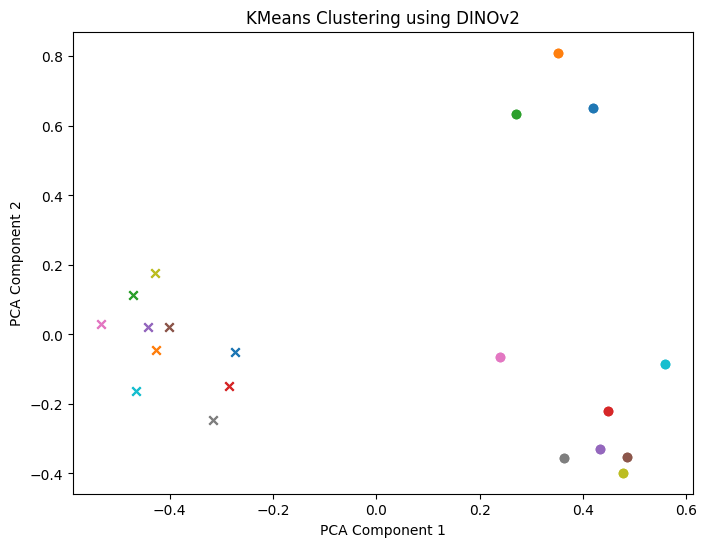

In [22]:
pca = PCA(n_components=2)

reduced_features = pca.fit_transform(features)

plt.figure(figsize=(8,6))

for i in range(len(reduced_features)):

    if predicted_clusters[i] == 0:

        plt.scatter(
            reduced_features[i, 0],
            reduced_features[i, 1],
            marker='o'
        )

    else:

        plt.scatter(
            reduced_features[i, 0],
            reduced_features[i, 1],
            marker='x'
        )

plt.title("KMeans Clustering using DINOv2")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [24]:
from io import BytesIO

In [26]:
import torch
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoImageProcessor, AutoModelForImageClassification

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id)

url = "https://images.unsplash.com/photo-1558788353-f76d92427f16"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

image = Image.open(BytesIO(response.content)).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

pred_class = logits.argmax(-1).item()
label = model.config.id2label[pred_class]

print(label)

Loading weights: 100%|██████████| 225/225 [00:00<00:00, 5244.72it/s]


golden retriever
